Будем анализировать датасет связанный с музыкой. Посмотрим какими стриминговыми сервисами пользуются люди и как влияет возраст на выбор стримингового сервиса. Также какие жанры предпочитают люди разных возрастных групп и сколько часов в день они проводят за прослушиванием музыки. И как музыкальные привычки влияют на психологическое состояние человека.

Для начала импортируем все необходимые библиотеки и сам датает.

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None) 

In [55]:
df = pd.read_csv('music_survey.csv')

Посмотрим на датаест, его размер и информацию о признаках.

In [56]:
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,BPM,Frequency [Classical],Frequency [Country],Frequency [EDM],Frequency [Folk],Frequency [Gospel],Frequency [Hip hop],Frequency [Jazz],Frequency [K pop],Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,156.0,Rarely,Never,Rarely,Never,Never,Sometimes,Never,Very frequently,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,119.0,Sometimes,Never,Never,Rarely,Sometimes,Rarely,Very frequently,Rarely,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,132.0,Never,Never,Very frequently,Never,Never,Rarely,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,Never,Never,Rarely,Sometimes,Never,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,107.0,Never,Never,Rarely,Never,Rarely,Very frequently,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [57]:
df.shape

(736, 33)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    str    
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    str    
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    str    
 5   Instrumentalist               732 non-null    str    
 6   Composer                      735 non-null    str    
 7   Fav genre                     736 non-null    str    
 8   Exploratory                   736 non-null    str    
 9   Foreign languages             732 non-null    str    
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    str    
 12  Frequency [Country]           736 non-null    str    
 13  Frequency [EDM] 

In [59]:
df.describe()

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,735.000000,736.000000,6.290000e+02,736.000000,736.000000,736.000000,736.000000
mean,25.206803,3.572758,1.589948e+06,5.837636,4.796196,3.738451,2.637228
std,12.054970,3.028199,3.987261e+07,2.793054,3.028870,3.088689,2.842017
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000


Начнем работу с пропусками. Посмотрим сколько пропусков в каждой из колонок.

In [60]:
df.isna().sum()

Timestamp                         0
Age                               1
Primary streaming service         1
Hours per day                     0
While working                     3
Instrumentalist                   4
Composer                          1
Fav genre                         0
Exploratory                       0
Foreign languages                 4
BPM                             107
Frequency [Classical]             0
Frequency [Country]               0
Frequency [EDM]                   0
Frequency [Folk]                  0
Frequency [Gospel]                0
Frequency [Hip hop]               0
Frequency [Jazz]                  0
Frequency [K pop]                 0
Frequency [Latin]                 0
Frequency [Lofi]                  0
Frequency [Metal]                 0
Frequency [Pop]                   0
Frequency [R&B]                   0
Frequency [Rap]                   0
Frequency [Rock]                  0
Frequency [Video game music]      0
Anxiety                     

Пропусков очень мало, за исключением столбца 'BPM'. Будем рассматривать несколько вариантов заполнения в зависимости от того, что этот признак собой представляет.

В колонке 'Age' всего одни пропуск, его заполним медианным занчением.

In [61]:
df['Age'] = df['Age'].fillna(df['Age'].median())

В столбце 'Primary streaming service' пропуск заполним значением 'I do not use a streaming service.' которое уже есть в этой колонке, так как считаем, что если человек не заполнил эту часть опроса, то он не пользуется никаким стриминговым сервисом.

In [62]:
df['Primary streaming service'].unique()

<StringArray>
[                          'Spotify',                           'Pandora',
                     'YouTube Music', 'I do not use a streaming service.',
                       'Apple Music',           'Other streaming service',
                                 nan]
Length: 7, dtype: str

In [63]:
df['Primary streaming service'] = df['Primary streaming service'].fillna('I do not use a streaming service.')

Пропуски в столбце 'While working' можно заполнить значением 'No', так как скорей всего, если человек не указал, что он слушает музыку во время работы, то он этого не делает.

In [64]:
df['While working'] = df['While working'].fillna('No')

По такому же принципу заполним пропуски в солбцах 'Instrumentalist', 'Composer', 'Foreign languages'.

In [65]:
df['Instrumentalist'] = df['Instrumentalist'].fillna('No')
df['Composer'] = df['Composer'].fillna('No')
df['Foreign languages'] = df['Foreign languages'].fillna('No')

Посмотрим какие значения есть в колонке 'Music effects' и заполним пропуски значением 'No effect', так как если человек ничего не укзал значит он не чувствует никакого влияния.

In [66]:
df['Music effects'].unique()

<StringArray>
[nan, 'No effect', 'Improve', 'Worsen']
Length: 4, dtype: str

In [67]:
df['Music effects'] = df['Music effects'].fillna('No effect')

In [68]:
df.isna().sum()

Timestamp                         0
Age                               0
Primary streaming service         0
Hours per day                     0
While working                     0
Instrumentalist                   0
Composer                          0
Fav genre                         0
Exploratory                       0
Foreign languages                 0
BPM                             107
Frequency [Classical]             0
Frequency [Country]               0
Frequency [EDM]                   0
Frequency [Folk]                  0
Frequency [Gospel]                0
Frequency [Hip hop]               0
Frequency [Jazz]                  0
Frequency [K pop]                 0
Frequency [Latin]                 0
Frequency [Lofi]                  0
Frequency [Metal]                 0
Frequency [Pop]                   0
Frequency [R&B]                   0
Frequency [Rap]                   0
Frequency [Rock]                  0
Frequency [Video game music]      0
Anxiety                     

Тепрь можем начать разбираться с пропусками в столбце BPM. Но как мы видим в этом столбце еще есть проблемы с выбросами. 

In [69]:
df['BPM'].describe()

count    6.290000e+02
mean     1.589948e+06
std      3.987261e+07
min      0.000000e+00
25%      1.000000e+02
50%      1.200000e+02
75%      1.440000e+02
max      1.000000e+09
Name: BPM, dtype: float64

In [70]:
df['BPM'].value_counts().sort_index()

BPM
0.0            3
4.0            1
8.0            1
20.0           1
40.0           1
              ..
210.0          2
218.0          1
220.0          2
624.0          1
999999999.0    1
Name: count, Length: 135, dtype: int64

После небольшого исследования я убедилась что значения bpm 0, 4, 8, 624 и тем более 999999999.0 с большой вероятностью являются выбросами. Избавимся от выбросов.

In [71]:
df.loc[(df["BPM"] < 20) | (df["BPM"] > 300), "BPM"] = np.nan

In [72]:
df["BPM"].describe()

count    622.00000
mean     123.59164
std       32.27175
min       20.00000
25%      100.00000
50%      120.00000
75%      144.00000
max      220.00000
Name: BPM, dtype: float64

Теперь когда мы превратили выбросы в пропуски заполним их меданным значением.

In [74]:
df["BPM"] = df["BPM"].fillna(df["BPM"].median())

Проверяем что пропуски отсутствуют. 

In [75]:
df.isna().sum().sum()

np.int64(0)

Еще обязательно проверим наличие дубликатов. Их нет.

In [77]:
df.duplicated().sum()

np.int64(0)

Разделим признаки на числовые и категориальные. Чтобы проанализировать их отдельно. Также не забудем проверить что все колонки попали в это распределение.

In [95]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print("Числовые колонки:", num_cols)
print("Категориальные колонки:", cat_cols)
print(len(num_cols), len(cat_cols))

Числовые колонки: ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
Категориальные колонки: ['Primary streaming service', 'While working', 'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory', 'Foreign languages', 'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]', 'Music effects', 'Permissions']
7 25


Timestamp нам не для чего не понадобиться поэтому можем его удалить. 

In [93]:
df.drop(columns=['Timestamp'], inplace=True)

In [98]:
for col in cat_cols:
    print(df[col].value_counts())
    print()

Primary streaming service
Spotify                              458
YouTube Music                         94
I do not use a streaming service.     72
Apple Music                           51
Other streaming service               50
Pandora                               11
Name: count, dtype: int64

While working
Yes    579
No     157
Name: count, dtype: int64

Instrumentalist
No     501
Yes    235
Name: count, dtype: int64

Composer
No     610
Yes    126
Name: count, dtype: int64

Fav genre
Rock                188
Pop                 114
Metal                88
Classical            53
Video game music     44
EDM                  37
R&B                  35
Hip hop              35
Folk                 30
K pop                26
Country              25
Rap                  22
Jazz                 20
Lofi                 10
Gospel                6
Latin                 3
Name: count, dtype: int64

Exploratory
Yes    525
No     211
Name: count, dtype: int64

Foreign languages
Yes    404
No  

Также удалим столбец Permissions так как только одно значение (столбец-константа)

In [99]:
df.drop(columns=['Permissions'], inplace=True)

Посмотрим на минимальные и максимальные значения в каждом числовом столбце.

In [108]:
for col in num_cols:
    print(df[col].value_counts().sort_index().head(5))

Age
10.0     1
12.0     3
13.0     8
14.0    17
15.0    21
Name: count, dtype: int64
Hours per day
0.00     6
0.10     1
0.25     3
0.50    20
0.70     1
Name: count, dtype: int64
BPM
20.0    1
40.0    1
52.0    1
55.0    2
56.0    1
Name: count, dtype: int64
Anxiety
0.0    35
1.0    29
2.0    44
3.0    69
4.0    56
Name: count, dtype: int64
Depression
0.0    84
1.0    40
2.0    93
3.0    59
3.5     2
Name: count, dtype: int64
Insomnia
0.0    149
1.0     82
2.0     88
3.0     68
3.5      1
Name: count, dtype: int64
OCD
0.0    248
1.0     95
2.0     96
3.0     64
4.0     48
Name: count, dtype: int64


In [109]:
for col in num_cols:
    print(df[col].value_counts().sort_index(ascending=False).head(5))

Age
89.0    1
80.0    1
74.0    1
73.0    1
72.0    1
Name: count, dtype: int64
Hours per day
24.0    3
20.0    1
18.0    1
16.0    1
15.0    2
Name: count, dtype: int64
BPM
220.0    2
218.0    1
210.0    2
208.0    1
204.0    1
Name: count, dtype: int64
Anxiety
10.0     67
9.0      56
8.0     115
7.5       1
7.0     122
Name: count, dtype: int64
Depression
10.0    45
9.0     38
8.0     77
7.0     96
6.0     88
Name: count, dtype: int64
Insomnia
10.0    34
9.0     27
8.0     49
7.0     59
6.0     62
Name: count, dtype: int64
OCD
10.0    20
9.0     14
8.5      1
8.0     28
7.0     34
Name: count, dtype: int64


24 часа выглядят подозрительно, но возможно. Поэтому я решила их оставить.

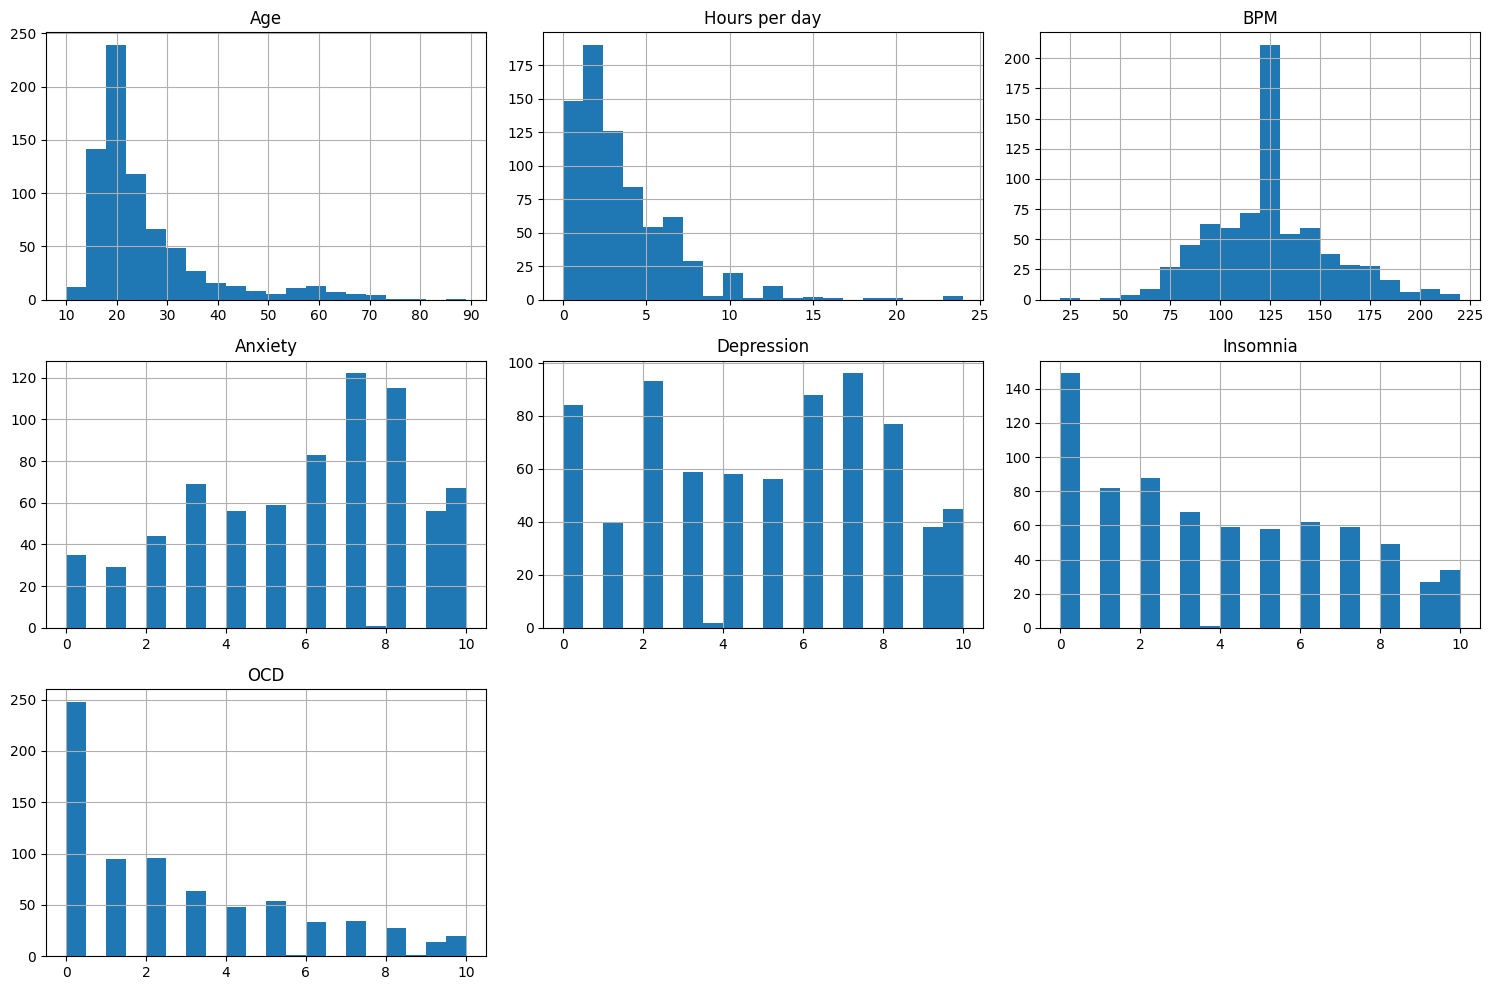

In [103]:
df.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

Теперь перейдем к вопросам на которые можно попробовать ответить с помощью этих данных.

Кто слушает музыку больше?

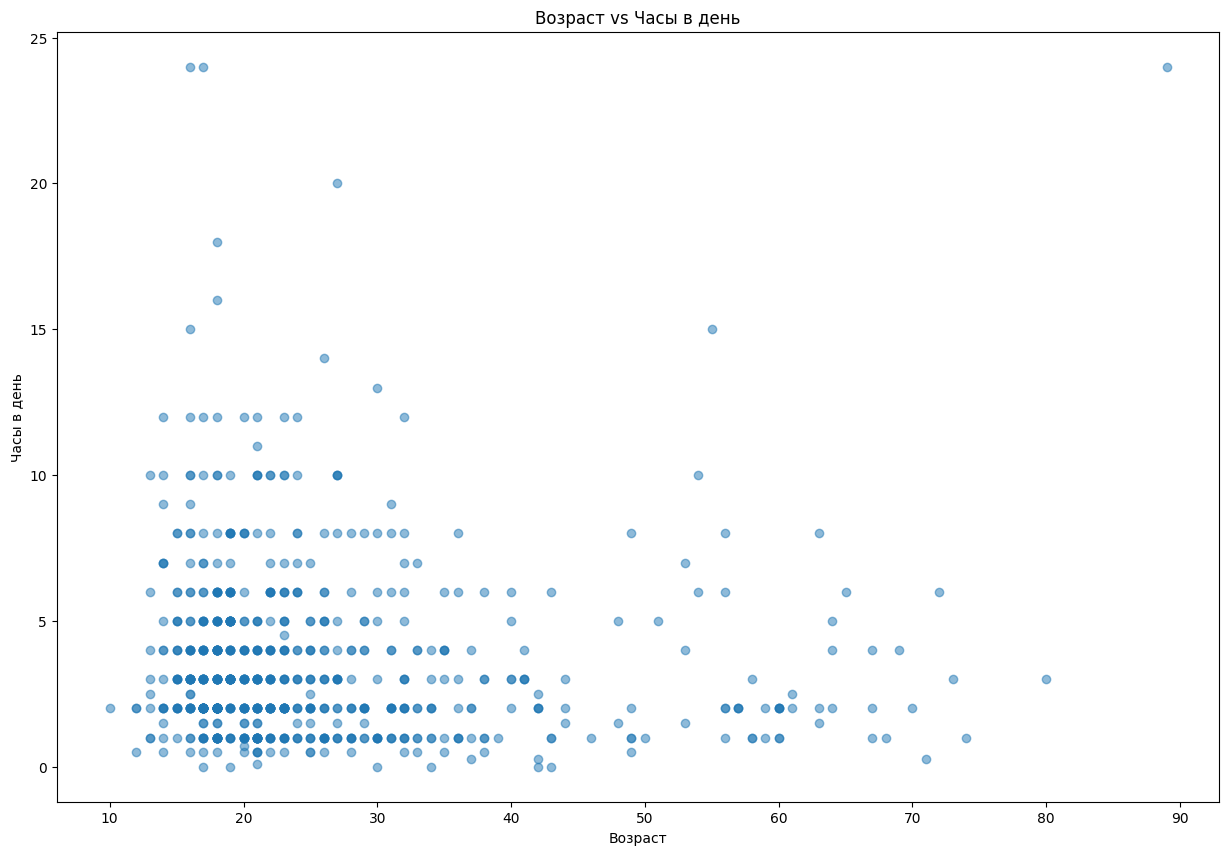

In [166]:
plt.figure(figsize=(15, 10))
plt.scatter(df['Age'], df['Hours per day'], alpha=0.5)
plt.xlabel('Возраст')
plt.ylabel('Часы в день')
plt.title('Возраст vs Часы в день')
plt.show()

In [167]:
bins = [0,18,25,35,50,100]

labels = [
    "<18",
    "18-25",
    "26-35",
    "36-50",
    "50+"
]

df["Age group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [168]:
df["Age group"].value_counts()

Age group
18-25    272
<18      238
26-35    129
36-50     50
50+       47
Name: count, dtype: int64

<Figure size 1500x1000 with 0 Axes>

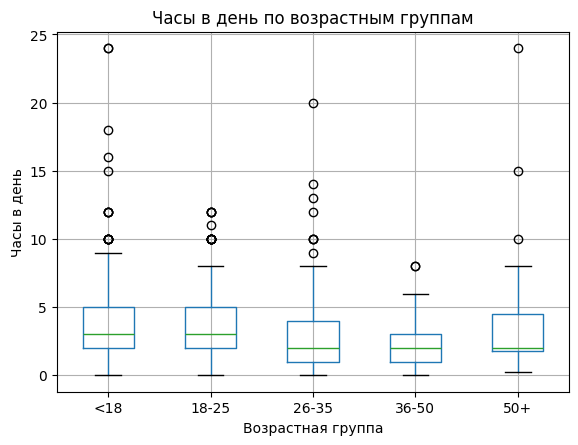

In [169]:
plt.figure(figsize=(15,10))

df.boxplot(
    column="Hours per day",
    by="Age group"
)

plt.title("Часы в день по возрастным группам")
plt.suptitle("")

plt.xlabel("Возрастная группа")
plt.ylabel("Часы в день")

plt.show()

In [116]:
df.groupby("Age group")["Hours per day"].agg(
    ["count","mean","median","std"]
)

,count,mean,median,std
Age group,,,,
<18,238,3.867647,3.0,3.360280
18-25,272,3.547059,3.0,2.526828
26-35,129,3.453488,2.0,3.148935
36-50,50,2.460000,2.0,1.983581
50+,47,3.739362,2.0,4.132637


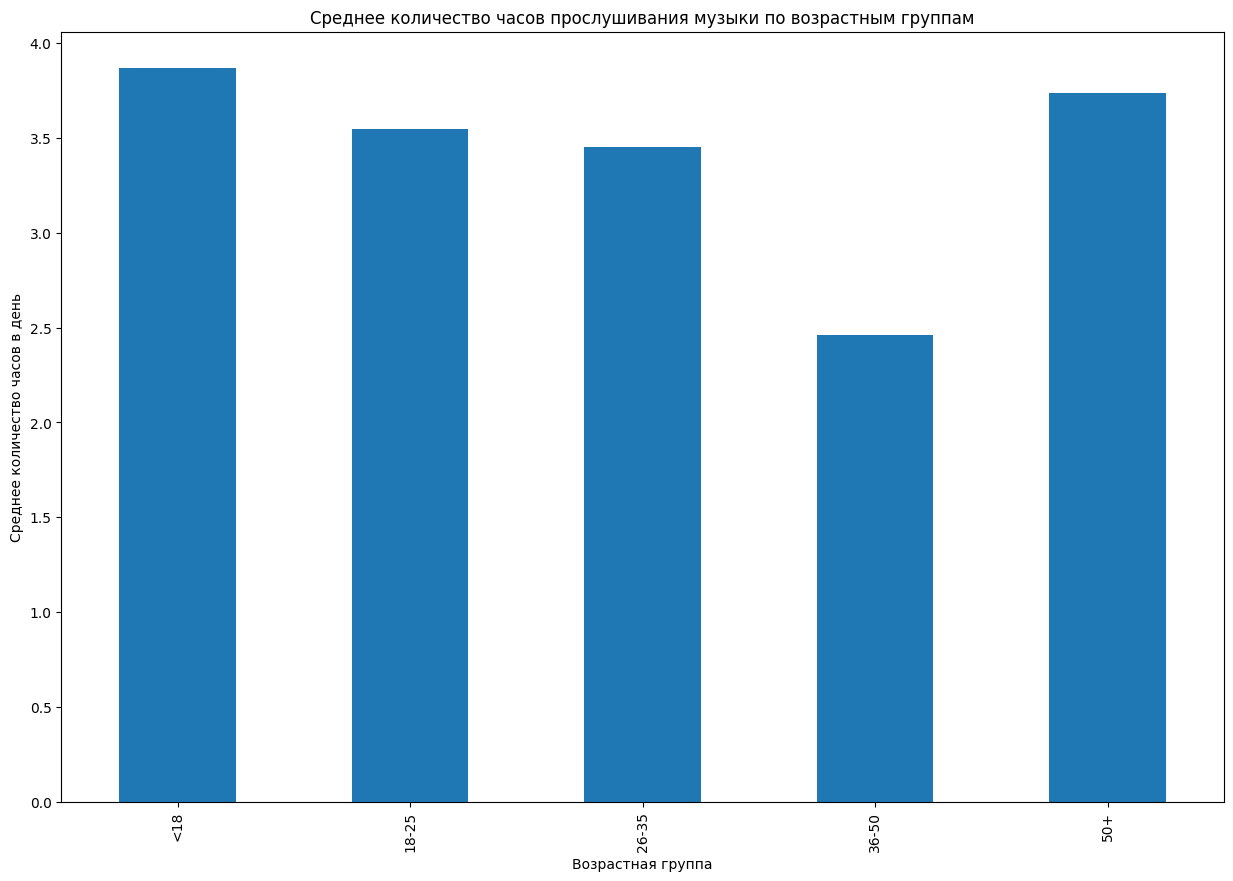

In [171]:
mean_hours = (
    df.groupby("Age group")["Hours per day"]
      .mean()
)
plt.figure(figsize=(15,10))
mean_hours.plot(kind="bar")
plt.xlabel("Возрастная группа")
plt.ylabel("Среднее количество часов в день")
plt.title("Среднее количество часов прослушивания музыки по возрастным группам")

plt.show()

Среднее время прослушивания музыки постепенно снижается от подростков к пользователям 36–50 лет. Однако для группы старше 50 лет среднее значение снова возрастает. При этом медиана в этой группе остается низкой (2 часа), а стандартное отклонение является самым высоким среди всех групп, что указывает на наличие пользователей с очень большим временем прослушивания. 

In [ ]:
genre_age = pd.crosstab(df["Age group"], df["Fav genre"])
genre_age

Fav genre,Classical,Country,EDM,Folk,Gospel,Hip hop,Jazz,K pop,Latin,Lofi,Metal,Pop,R&B,Rap,Rock,Video game music
Age group,,,,,,,,,,,,,,,,
<18,21,4,13,7,1,13,6,15,3,3,18,43,16,12,45,18
18-25,15,13,16,10,0,11,8,10,0,5,35,47,12,8,62,20
26-35,8,5,7,9,0,8,4,1,0,2,25,13,2,1,42,2
36-50,4,2,1,4,0,2,0,0,0,0,10,5,0,0,18,4
50+,5,1,0,0,5,1,2,0,0,0,0,6,5,1,21,0


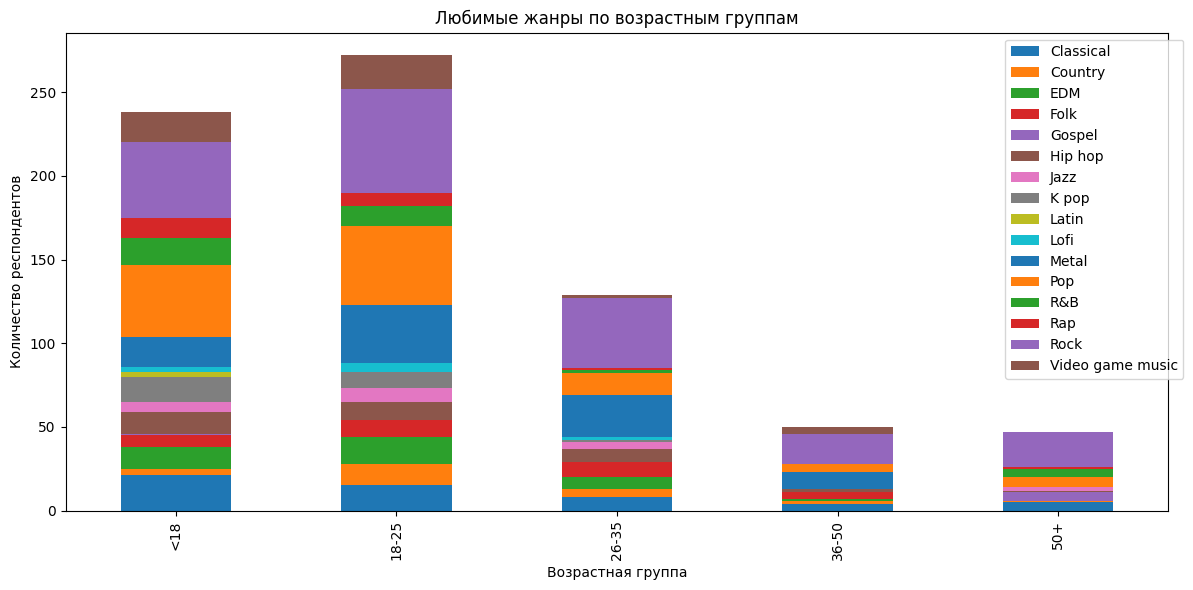

In [172]:
genre_age.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.xlabel("Возрастная группа")
plt.ylabel("Количество респондентов")
plt.title("Любимые жанры по возрастным группам")

plt.legend(bbox_to_anchor=(1.02,1))
plt.tight_layout()

plt.show()

In [143]:
genre_percent = pd.crosstab(df["Age group"], df["Fav genre"], normalize="index") * 100

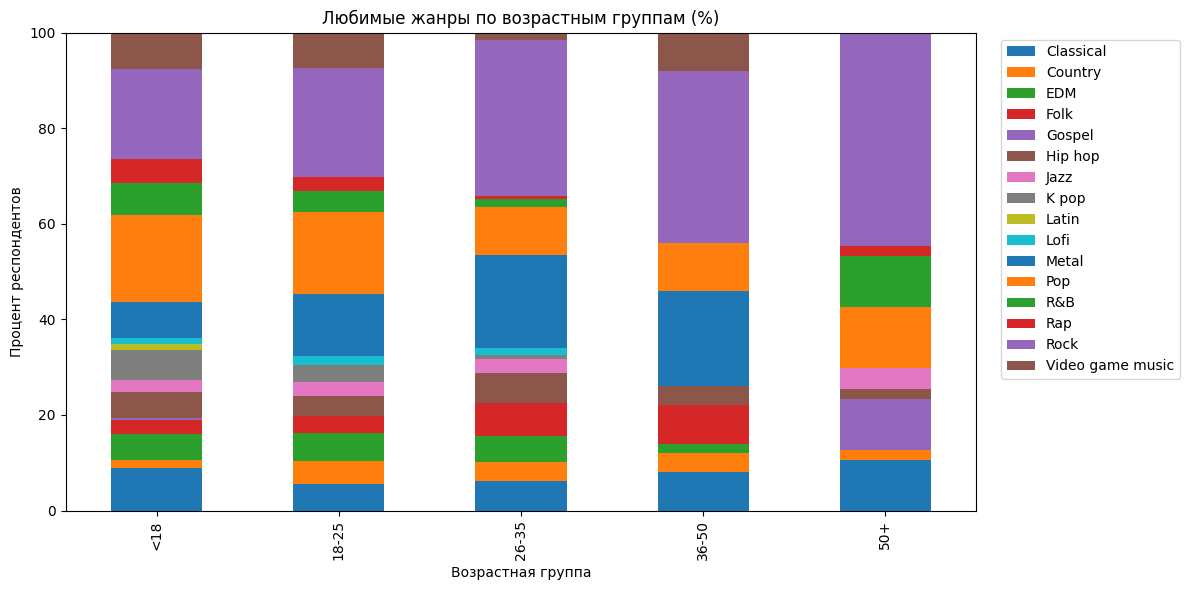

In [173]:
genre_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)
plt.xlabel("Возрастная группа") 
plt.ylabel("Процент респондентов")
plt.title("Любимые жанры по возрастным группам (%)")

plt.legend(bbox_to_anchor=(1.02,1))

plt.tight_layout()

plt.show()

In [135]:
df.groupby("Age group")["Fav genre"].value_counts().groupby(level=0).head(3)


Age group  Fav genre
<18        Rock         45
           Pop          43
           Classical    21
18-25      Rock         62
           Pop          47
           Metal        35
26-35      Rock         42
           Metal        25
           Pop          13
36-50      Rock         18
           Metal        10
           Pop           5
50+        Rock         21
           Pop           6
           Classical     5
Name: count, dtype: int64

Во всех возрастных группах наиболее популярным жанром является Rock. Он занимает первое место независимо от возраста пользователей, что говорит о его универсальной популярности в данной выборке.

Вторым по популярности жанром у большинства групп является Pop. Однако с увеличением возраста количество пользователей, предпочитающих Pop, постепенно снижается. Например, в группе младше 18 лет этот жанр выбрали 43 человека, тогда как среди пользователей старше 50 лет — только 6.

Жанр Metal наиболее популярен среди пользователей в возрасте 18–50 лет, а в группе 50+ этот жанр даже не встречается.

Среди пользователей младше 18 лет наблюдается большее разнообразие музыкальных предпочтений: помимо Rock и Pop, относительно высокой популярностью пользуются Classical, Video game music, Metal и K-pop.

У пользователей старше 50 лет музыкальные предпочтения становятся менее разнообразными. Помимо Rock, сравнительно чаще выбираются Pop и Classical, тогда как современные жанры практически отсутствуют. И только это поколение слушает Gospel.

Анализ показывает, что музыкальные предпочтения различаются между возрастными группами. При этом Rock остается наиболее популярным жанром независимо от возраста, тогда как популярность других жанров меняется. 

Какие стриминговы сервисы предпочитают пользователи?

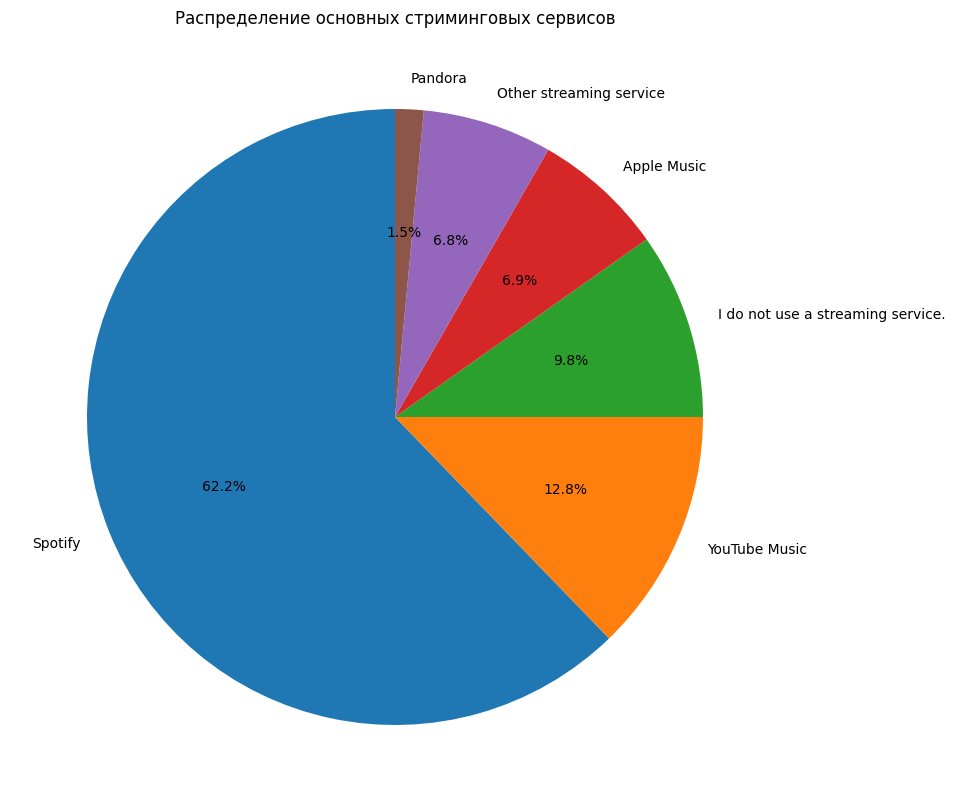

In [174]:
streaming_counts = df["Primary streaming service"].value_counts()
plt.figure(figsize=(10, 10))
plt.pie(
    streaming_counts,
    labels=streaming_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Распределение основных стриминговых сервисов")
plt.show()

In [140]:
streaming_counts

Primary streaming service
Spotify                              458
YouTube Music                         94
I do not use a streaming service.     72
Apple Music                           51
Other streaming service               50
Pandora                               11
Name: count, dtype: int64

Анализ распределения основных стриминговых сервисов показал, что Spotify является безусловным лидером среди участников опроса. Его используют 458 из 736 респондентов (около 62%), что значительно превышает популярность остальных платформ.

Второе место занимает YouTube Music — 94 пользователя (около 13%). Далее следуют пользователи, которые не используют стриминговые сервисы (72 человека, около 10%), а также Apple Music (51 человек, около 7%) и Other streaming service (50 человек, около 7%). Наименее популярным сервисом в выборке оказалась Pandora, которой пользуются всего 11 респондентов (около 1,5%).

Полученные результаты свидетельствуют о высокой концентрации рынка: большинство участников исследования используют один сервис — Spotify, тогда как остальные платформы представлены значительно меньшими долями.

Также посмотрим какие стриминговые сервисы выбирают возрастные группы.

In [147]:
service_age = pd.crosstab(df['Age group'], df['Primary streaming service'])
service_age

Primary streaming service,Apple Music,I do not use a streaming service.,Other streaming service,Pandora,Spotify,YouTube Music
Age group,,,,,,
<18,19,11,15,1,168,24
18-25,20,30,10,1,176,35
26-35,6,11,11,1,84,16
36-50,3,9,6,1,23,8
50+,3,11,8,7,7,11


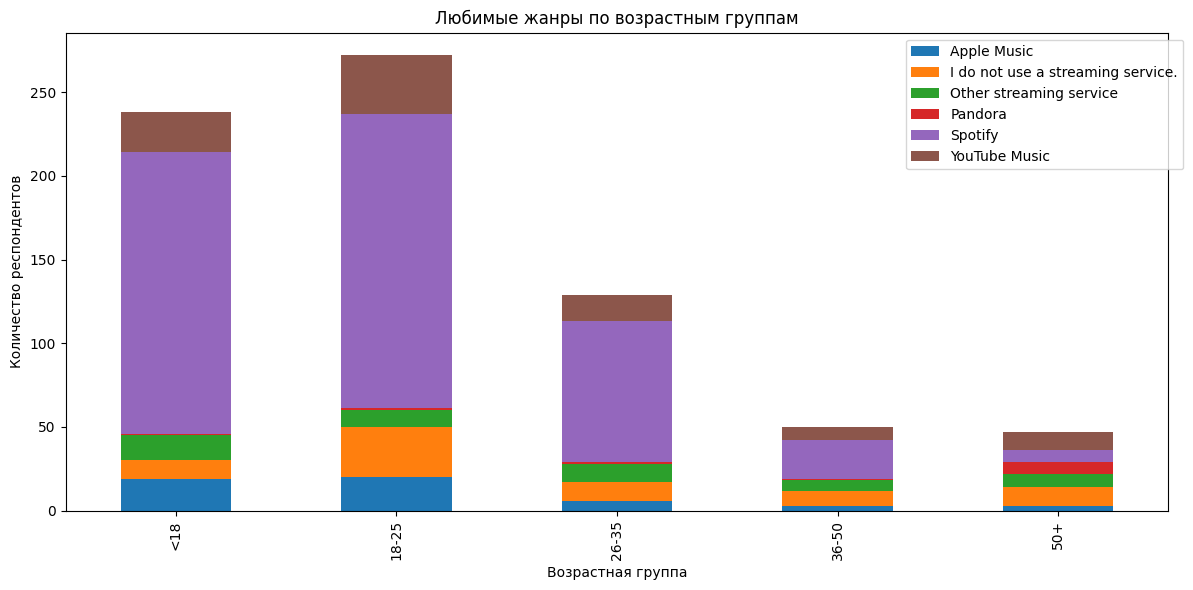

In [175]:
service_age.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.xlabel("Возрастная группа")
plt.ylabel("Количество респондентов")
plt.title("Любимые жанры по возрастным группам")

plt.legend(bbox_to_anchor=(1.02,1))
plt.tight_layout()

plt.show()

Абсолютный лидер во всех возрастах Spotify. Он доминирует, особенно среди молодёжи <18 и 18-25.

YouTube Music уверенный второй номер. Его аудитория также сосредоточена в молодых возрастных группах, но с возрастом популярность резко падает.

Apple Music — третий по популярности. Показывает стабильно низкие цифры (от 3 до 20) во всех группах.

Интересный всплеск у группы 50+ для Pandora:
В этой возрастной группе Pandora получает 7 голосов, что сопоставимо с YouTube Music (11) и даже выше, чем Apple Music (3). Это может указывать на то, что Pandora сохранила лояльную аудиторию более старшего возраста.

"I do not use a streaming service" таких людей больше всего в возрастной группе от 18 до 25 лет.

"Other streaming service" — стабильно низкие значения (от 6 до 15), что говорит о сильной сосредоточенности рынка вокруг нескольких крупных игроков.

Перейдем к главному вопросу: как влияет музыка на психологическое состояние слушателей.

In [148]:
mental_cols = [
    "Anxiety",
    "Depression",
    "Insomnia",
    "OCD"
]

df.groupby("Music effects")[mental_cols].mean()

,Anxiety,Depression,Insomnia,OCD
Music effects,,,,
Improve,6.047048,4.861624,3.755535,2.719557
No effect,5.107345,4.367232,3.610169,2.338983
Worsen,6.764706,7.176471,4.529412,3.117647


Группа “Worsen” имеет самые высокие средние значения по всем показателям.

Участники, которые считают, что музыка ухудшает их состояние, в среднем сообщают о более высоких уровнях: тревожности, депрессии, бессонницы, симптомов ОКР.

Особенно заметно это для депрессии (7.18 против 4.86 и 4.37).

Группа “No effect” имеет самые низкие показатели.

Респонденты, не замечающие влияния музыки на свое состояние, в среднем имеют более низкие значения всех четырех психологических показателей.

Интересное наблюдение по группе “Improve”.

Выглядит странно чтоо люди, считающие, что музыка помогает, имеют более высокие уровни тревожности и депрессии, чем группа “No effect”.

Могу попробовать объяснить это следующим образом: возможно, именно люди, испытывающие более выраженные психологические трудности, чаще используют музыку как способ эмоциональной поддержки и поэтому отмечают положительное влияние музыки.

Но это гипотеза, а не доказанный факт.

<Figure size 700x500 with 0 Axes>

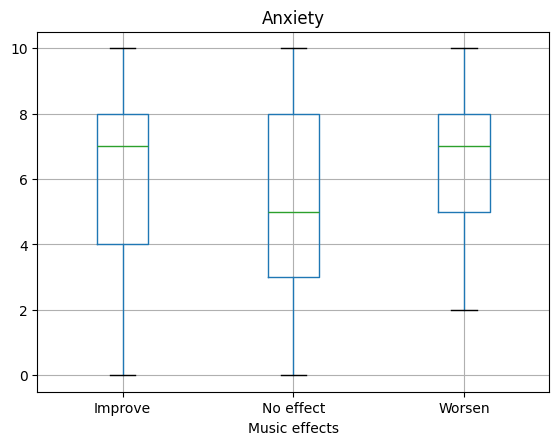

<Figure size 700x500 with 0 Axes>

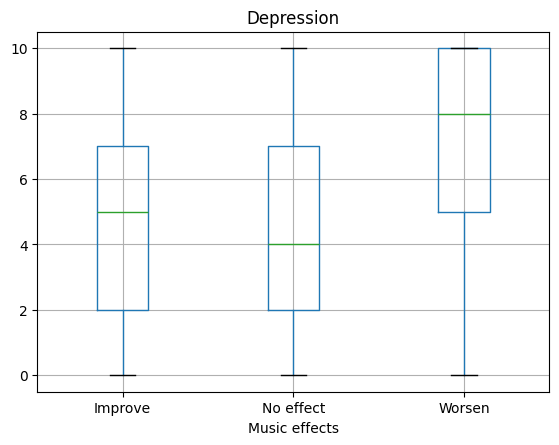

<Figure size 700x500 with 0 Axes>

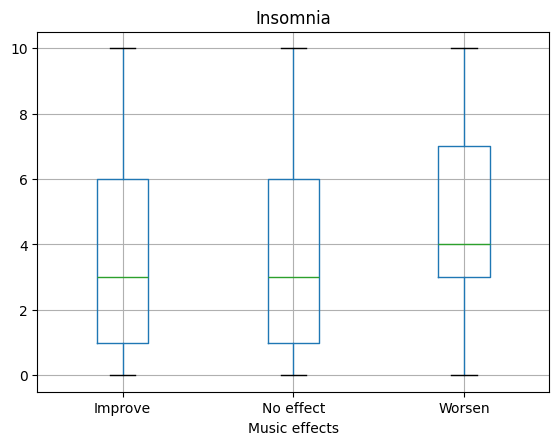

<Figure size 700x500 with 0 Axes>

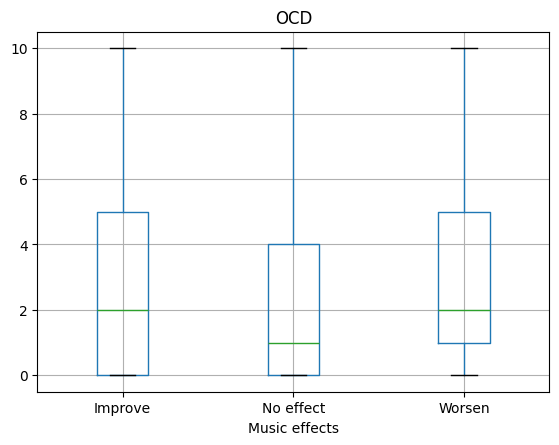

In [150]:
for col in mental_cols:

    plt.figure(figsize=(7,5))

    df.boxplot(
        column=col,
        by="Music effects"
    )

    plt.title(col)
    plt.suptitle("")
    plt.show()

In [151]:
from scipy.stats import kruskal

for col in mental_cols:

    groups = [
        group[col].dropna().values
        for _, group in df.groupby("Music effects")
    ]

    stat, p = kruskal(*groups)

    print(f"{col}:")
    print(f"H = {stat:.3f}")
    print(f"p = {p:.4f}")
    print()

Anxiety:
H = 13.485
p = 0.0012

Depression:
H = 13.745
p = 0.0010

Insomnia:
H = 2.090
p = 0.3517

OCD:
H = 4.574
p = 0.1016



Для оценки различий между группами пользователей, по-разному оценивающими влияние музыки на свое состояние, был использован непараметрический критерий Kruskal–Wallis. Выбор данного теста обусловлен тем, что исследуемые показатели не соответствуют нормальному распределению, а сравнение проводилось между тремя независимыми группами.

Результаты показали статистически значимые различия по уровню тревожности (H = 13.49, p = 0.0012) и депрессии (H = 13.75, p = 0.0010). При этом для бессонницы (p = 0.3517) и симптомов ОКР (p = 0.1016) статистически значимых различий обнаружено не было.

По описательной статистике наиболее высокие уровни тревожности и депрессии наблюдались у респондентов, считающих, что музыка ухудшает их состояние, а наиболее низкие у тех, кто не отмечает влияния музыки.


In [152]:
df["Mental score"] = (
    df["Anxiety"] +
    df["Depression"] +
    df["Insomnia"] +
    df["OCD"]
)

In [154]:
df.groupby("Music effects")["Mental score"].mean()

Music effects
Improve      17.383764
No effect    15.423729
Worsen       21.588235
Name: Mental score, dtype: float64

Для комплексной оценки психологического состояния был сформирован интегральный показатель Mental score, представляющий собой сумму оценок тревожности, депрессии, бессонницы и симптомов ОКР.

Наименьшее среднее значение Mental score наблюдается у группы No effect.

Средний показатель составляет 15,42. Это означает, что респонденты, не отмечающие влияния музыки на свое состояние, в среднем сообщают о менее выраженных психологических симптомах.

Группа Improve среднее значение 17,38, что выше, чем у группы No effect.

Это интересный результат. Он показывает, что люди, считающие музыку полезной, не являются психологически более благополучными. Напротив, их суммарный уровень психологических симптомов немного выше.

Самое высокое значение наблюдается у группы Worsen. Средний показатель составляет 21,59.

Это означает, что именно эта группа имеет наиболее высокую суммарную выраженность психологических симптомов.

Однако здесь необходимо учитывать важное ограничение исследования: в группе Worsen всего 17 человек, поэтому оценки для нее менее устойчивы и могут сильнее зависеть от отдельных наблюдений.

Респонденты, сообщающие о том, что музыка ухудшает их состояние, в среднем имеют более высокий уровень психологических симптомов. 

In [158]:
age_effect = pd.crosstab(df["Age group"], df["Music effects"])
age_effect

Music effects,Improve,No effect,Worsen
Age group,,,
<18,189,43,6
18-25,204,62,6
26-35,82,44,3
36-50,33,15,2
50+,34,13,0


Анализ распределения ответов показал, что во всех возрастных группах большинство респондентов считают, что музыка оказывает положительное влияние на их состояние. Доля ответов “Improve” существенно превышает количество ответов No effect и Worsen независимо от возраста.

Ответ “No effect” занимает второе место по распространенности во всех возрастных группах. При этом количество таких ответов заметно ниже, чем ответов Improve.

Ответ “Worsen” встречается крайне редко во всех возрастных категориях. В группе 50+ респонденты вовсе не отметили, что музыка ухудшает их состояние, а в остальных возрастных группах количество таких ответов не превышает 2–6 человек.

Но в принципе у нас в целом по датасету такая статистика, что очень много ответов о положительном влиянии и очень мало о негативном. Я бы сказала что тут не сильно заметна разница между возраснтыми группами, за исключением отсутствия негативного влияния у группы 50+.

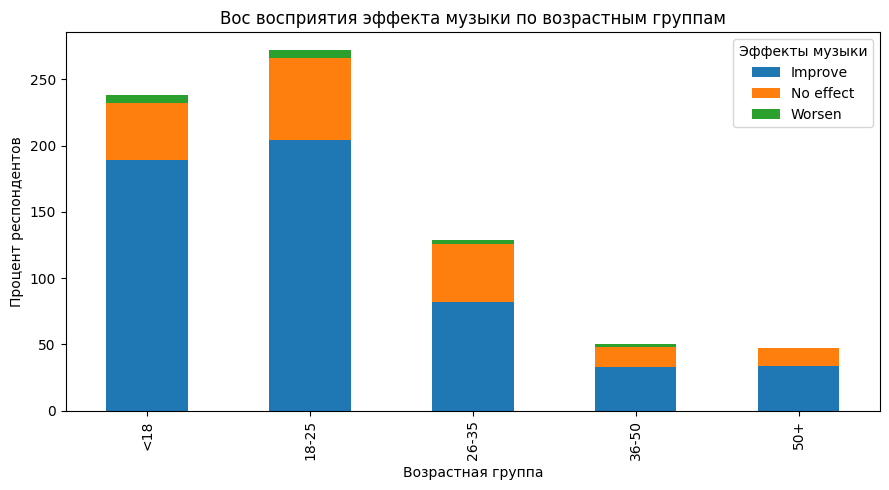

In [177]:
age_effect.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5)
)
plt.xlabel("Возрастная группа")
plt.ylabel("Процент респондентов")
plt.title("Вос восприятия эффекта музыки по возрастным группам")
plt.legend(title="Эффекты музыки")
plt.tight_layout()

plt.show()

In [160]:
genre_effect = pd.crosstab(
    df["Fav genre"],
    df["Music effects"]
)

genre_effect

Music effects,Improve,No effect,Worsen
Fav genre,,,
Classical,39,13,1
Country,20,5,0
EDM,30,7,0
Folk,23,7,0
Gospel,6,0,0
Hip hop,31,4,0
Jazz,16,4,0
K pop,19,7,0
Latin,1,2,0


In [165]:
genre_effect_percent = pd.crosstab(
    df["Fav genre"],
    df["Music effects"],
    normalize="index"
) * 100

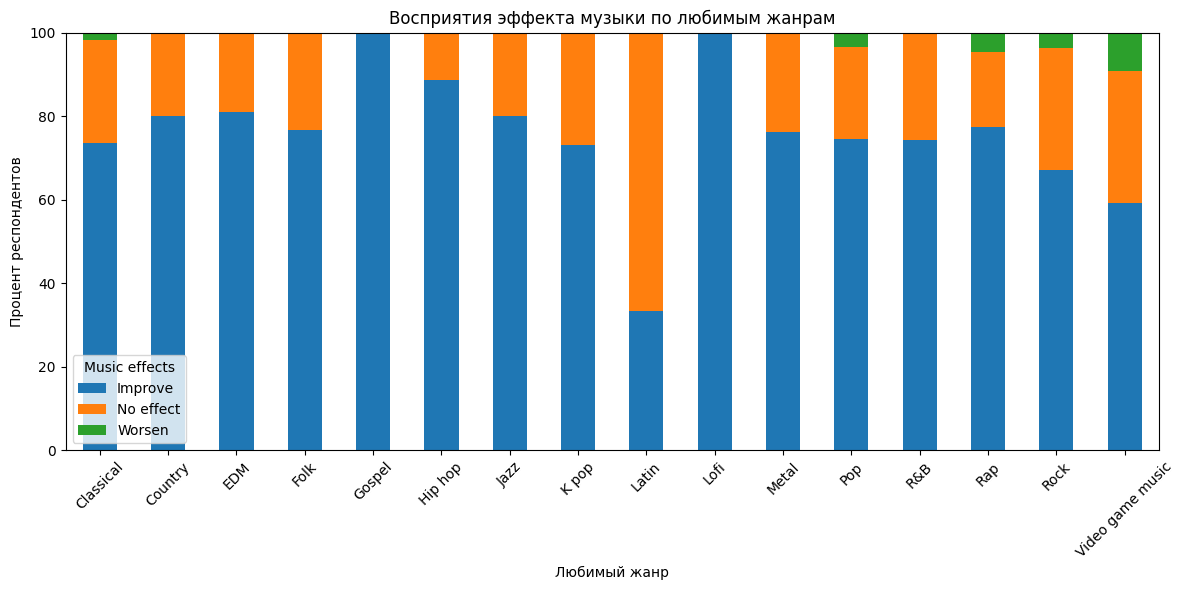

In [178]:
genre_effect_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)
plt.xlabel("Любимый жанр")
plt.ylabel("Процент респондентов")
plt.title("Восприятия эффекта музыки по любимым жанрам")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Анализ показал, что независимо от любимого музыкального жанра большинство респондентов считают, что музыка оказывает положительное влияние на их состояние. Для всех жанров ответ Improve встречается значительно чаще, чем No effect или Worsen.

Наибольшее количество положительных оценок наблюдается среди любителей наиболее популярных жанров выборки — Rock, Pop и Metal. Однако это во многом объясняется тем, что именно эти жанры имеют наибольшее число поклонников в исследуемой выборке.

Ответ No effect занимает второе место практически для всех жанров. Наибольшее количество таких ответов также приходится на Rock, Pop и Metal.

Ответ Worsen встречается крайне редко. Он отмечен только среди любителей Rock, Pop, Video game music, Rap и Classical, причем количество таких ответов не превышает нескольких человек. Для большинства остальных жанров респонденты вовсе не сообщили об ухудшении состояния под влиянием музыки.

Также можно заметить, что у жанра Gospel исключительно положительное влияние, но его слушают не так много человек, поэтому нельзя утверждать точно.

Особый интерес представляет жанр Video game music: несмотря на небольшое число поклонников, именно среди них наблюдается относительно больше ответов Worsen (4 человека из 44, около 9%). Однако из-за небольшого объема группы этот результат следует интерпретировать с осторожностью и не рассматривать как доказательство негативного влияния данного жанра.

ЗАКЛЮЧЕНИЕ

В ходе исследования был проведен полный цикл анализа данных: выполнена предобработка датасета, обработаны пропуски и выбросы, проведен разведочный анализ данных (EDA), построены визуализации и проверены статистические гипотезы.

Анализ показал, что большинство участников исследования — молодые пользователи в возрасте до 25 лет, а наиболее популярным стриминговым сервисом является Spotify, которым пользуются около 62% респондентов. Среди музыкальных жанров лидирует Rock, который оказался самым популярным во всех возрастных группах, тогда как предпочтения к другим жанрам меняются с возрастом.

Исследование связи между возрастом и временем прослушивания музыки показало, что наиболее высокое среднее время прослушивания наблюдалось у пользователей младше 18 лет, а наименьшее — у группы 36–50 лет. Однако разброс значений внутри возрастных групп остается достаточно высоким, поэтому возраст нельзя рассматривать как единственный фактор, влияющий на продолжительность прослушивания музыки.

Анализ музыкальных предпочтений показал, что возраст связан с выбором любимого жанра. Независимо от возраста наиболее популярным жанром остается Rock, однако среди молодых пользователей чаще встречаются Pop, K-pop и Video game music, тогда как среди старших возрастных групп относительно выше интерес к Classical, Gospel и снижается популярность современных жанров.

Особое внимание было уделено исследованию связи между восприятием влияния музыки и психологическими показателями. Для сравнения трех независимых групп пользователей (Improve, No effect и Worsen) был использован непараметрический критерий Kruskal–Wallis, поскольку исследуемые показатели не соответствовали нормальному распределению. Результаты показали статистически значимые различия по уровню тревожности (p = 0.0012) и депрессии (p = 0.0010). При этом для бессонницы и симптомов ОКР статистически значимых различий обнаружено не было. Пользователи, считающие, что музыка ухудшает их состояние, в среднем демонстрировали наиболее высокие уровни тревожности и депрессии, тогда как самые низкие значения наблюдались у респондентов, не отмечающих влияния музыки.

Также был рассчитан интегральный показатель Mental score, объединяющий оценки тревожности, депрессии, бессонницы и симптомов ОКР. Он подтвердил ранее выявленную тенденцию: наиболее высокий суммарный уровень психологических симптомов наблюдался у группы Worsen, а наиболее низкий — у группы No effect.

В целом исследование показало, что музыкальные предпочтения и субъективное восприятие влияния музыки связаны с рядом характеристик пользователей.